<a href="https://colab.research.google.com/github/Xketh/P1_Pratico_Wine.ipynb/blob/main/P1_Pratico_Kethilyn_1131392223013__Wine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# P1 – Parte Prática (Grupo 2) — **Wine**
**Disciplina:** ISW-039 – Mineração de Dados (FATEC Mauá)  
**Professor:** Lucas B. Henrique  
**Dataset do Grupo 2:** `sklearn.datasets.load_wine()`  
**Data:** 2025-09-27

## Instruções
- Este notebook compõe a **Parte C (4,0 pts)** da P1 e deve ser **entregue pelo representante do grupo** no Teams como `P1_Pratico_Grupo2_Wine.ipynb`, acompanhado de um pequeno `README.md` com instruções de execução.
- Trabalho em grupo, mas **todos os integrantes** devem ser capazes de explicar as decisões tomadas.
- Utilize **apenas** bibliotecas trabalhadas até o momento: `pandas`, `numpy`, `matplotlib`, `scikit-learn` (básico).
- **Semente (reprodutibilidade):** use `random_state=42` onde aplicável.
- **Divisão de dados:** `train_test_split(..., test_size=0.2, stratify=y, random_state=42)`.
- Responda os **prompts de análise** (texto) ao final de cada seção.

> **Observação do dataset:** O **Wine** tem 13 atributos químicos em **escalas diferentes**. A **padronização** influencia bastante no desempenho do k-NN.


# 🛠️ **1) Setup e versões**

> Rodar todas as bibliotecas e verificar se a versão do Python está atualizada:



In [28]:

import sys, platform
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

import sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report)
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.decomposition import PCA

print("Python:", sys.version.split()[0])
print("OS:", platform.platform())
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)


Python: 3.12.11
OS: Linux-6.6.97+-x86_64-with-glibc2.35
numpy: 2.0.2
pandas: 2.2.2
scikit-learn: 1.6.1


### **Resultado:**

* Python 3.12.11 → ok, recente

* NumPy 2.0.2 → ok

* Pandas 2.2.2 → ok

* Scikit-learn 1.6.1 → ok

**Sem problemas para seguir o código!!!**

# 📥 **2) Carregamento do dataset (Wine)**

**Resumo:**

* **X_raw =** as características químicas do vinho

* **y_raw =** tipo de vinho (classe)

* **target_names =** nomes dos tipos de vinho


* **13 colunas químicas:** álcool, magnésio, fenóis…

* **Rótulo =** tipo de vinho (0, 1, 2)

<br>

In [29]:

from sklearn.datasets import load_wine

data = load_wine(as_frame=True)
X_raw = data.data.copy()
y_raw = data.target.copy()
target_names = list(data.target_names)

print("Shape X:", X_raw.shape, "| Shape y:", y_raw.shape)
X_raw.head()


Shape X: (178, 13) | Shape y: (178,)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


# 📖 **3) Dicionário de dados**

### **Atributos químicos**

O dataset Wine tem dados de 178 vinhos diferentes.

Cada vinho tem 13 atributos químicos que mostram características como álcool, acidez, minerais e compostos fenólicos.

O objetivo é usar essas informações para **identificar o tipo de vinho** (0, 1 ou 2).

* `alcohol` → quantidade de álcool no vinho  
* `malic_acid` → quantidade de ácido málico  
* `ash` → resíduo sólido após queimar o vinho  
* `alcalinity_of_ash` → alcalinidade das cinzas  
* `magnesium` → qtd de magnésio  
* `total_phenols` → qtd de fenóis totais  
* `flavanoids` → qtd de flavonoides  
* `nonflavanoid_phenols` → fenóis que não são flavonoides  
* `proanthocyanins` → outro tipo de composto fenólico  
* `color_intensity` → intensidade da cor do vinho  
* `hue` → tonalidade da cor  
* `od280/od315_of_diluted_wines` → medida da absorção de luz (indica compostos fenólicos)  
* `proline` → qtd de prolina (aminoácido)  

* **`target` → tipo do vinho: 0, 1 ou 2 (classe que queremos prever).**





# 🧹 **4) Qualidade dos dados:** valores ausentes, duplicados

Antes de começar a analisar ou treinar modelos, precisa checar se os dados estão “limpos”.
#

O código abaixo faz duas coisas:

1. Primeiro ele verifica se alguma coluna tem **valores faltando (NA)** e mostra a proporção em cada coluna. Em análise de dados, a gente precisa decidir o que fazer com esses valores faltando: Se preenchemos com média/mediana, ou removemos a linha, dependendo do que faz mais sentido.

2. Conta quantas **linhas duplicadas** existem na tabela. Porque se houver, geralmente é seguro remover porque não adicionam informação nova.



In [30]:

na_rate = X_raw.isna().mean().sort_values(ascending=False)
dup_count = pd.concat([X_raw, y_raw], axis=1).duplicated().sum()
display(pd.DataFrame({"na_rate": na_rate}))
print("Duplicados (linhas completas):", dup_count)


,na_rate
alcohol,0.0
malic_acid,0.0
ash,0.0
alcalinity_of_ash,0.0
magnesium,0.0
total_phenols,0.0
flavanoids,0.0
nonflavanoid_phenols,0.0
proanthocyanins,0.0
color_intensity,0.0


Duplicados (linhas completas): 0


> Não existem valores ausentes e também não tem duplicatas relevantes. Os dados estão limpos e prontos para a análise, Não precisa preencher ou remover linhas.


# 📊 **5) Estatística descritiva e distribuição**

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


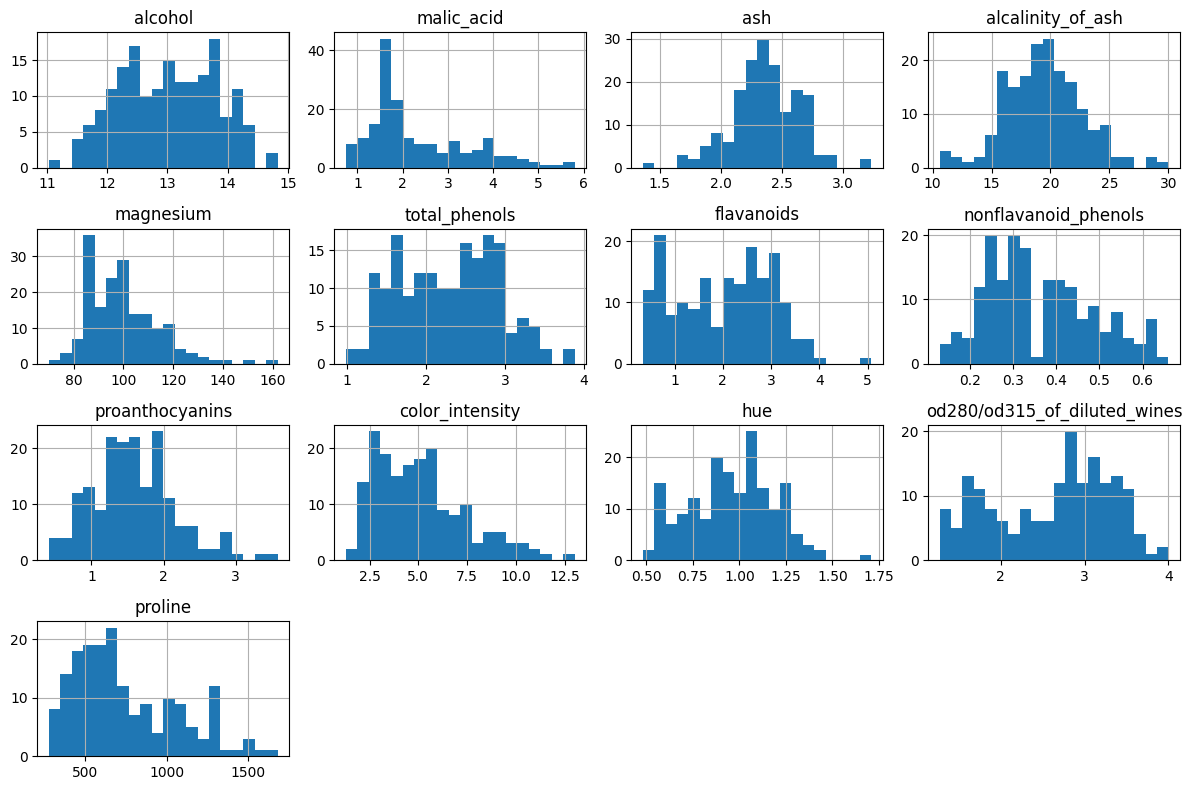

In [31]:

desc = X_raw.describe().T
display(desc)

axes = X_raw.hist(bins=20, figsize=(12,8))
plt.tight_layout(); plt.show()


### **Média vs Mediana e Dispersão**

> Se você observar, vai ver que a média e a mediana  do "álcool" ficaram quase iquais, então os valores estão equilibrados.

> Já no "ácido málico", a média ficou bem maior que a mediana, ou seja, tem valores que estão puxando pra cima, o que faz a gente pensar nos **outliers** que nada mais é que os "valores estranhos".
#


* **Média:** (soma tudo e divide pela quantidade (ex.: notas 7, 8, 9 → média = 8, porque 7+8+9= 24 / 3 = 8)

* **Mediana** (que é o valor do meio quando você coloca em ordem (ex.: notas 7, 8, 9 → 8)

* **Dispersão:** Mostra se os valores estão bem espalhados ou concentrados. Valores muito diferentes indicam mais variação.

# 🔗 **6) Correlação entre variáveis numéricas**

In [32]:

corr = X_raw.corr(numeric_only=True)
corr


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
alcohol,1.000000,0.094397,0.211545,-0.310235,0.270798,0.289101,0.236815,-0.155929,0.136698,0.546364,-0.071747,0.072343,0.643720
malic_acid,0.094397,1.000000,0.164045,0.288500,-0.054575,-0.335167,-0.411007,0.292977,-0.220746,0.248985,-0.561296,-0.368710,-0.192011
ash,0.211545,0.164045,1.000000,0.443367,0.286587,0.128980,0.115077,0.186230,0.009652,0.258887,-0.074667,0.003911,0.223626
alcalinity_of_ash,-0.310235,0.288500,0.443367,1.000000,-0.083333,-0.321113,-0.351370,0.361922,-0.197327,0.018732,-0.273955,-0.276769,-0.440597
magnesium,0.270798,-0.054575,0.286587,-0.083333,1.000000,0.214401,0.195784,-0.256294,0.236441,0.199950,0.055398,0.066004,0.393351
total_phenols,0.289101,-0.335167,0.128980,-0.321113,0.214401,1.000000,0.864564,-0.449935,0.612413,-0.055136,0.433681,0.699949,0.498115
flavanoids,0.236815,-0.411007,0.115077,-0.351370,0.195784,0.864564,1.000000,-0.537900,0.652692,-0.172379,0.543479,0.787194,0.494193
nonflavanoid_phenols,-0.155929,0.292977,0.186230,0.361922,-0.256294,-0.449935,-0.537900,1.000000,-0.365845,0.139057,-0.262640,-0.503270,-0.311385
proanthocyanins,0.136698,-0.220746,0.009652,-0.197327,0.236441,0.612413,0.652692,-0.365845,1.000000,-0.025250,0.295544,0.519067,0.330417
color_intensity,0.546364,0.248985,0.258887,0.018732,0.199950,-0.055136,-0.172379,0.139057,-0.025250,1.000000,-0.521813,-0.428815,0.316100


> **Correlação:** mostra se duas coisas mudam juntas

* Positiva → se uma aumenta, a outra também aumenta

* Negativa → se uma aumenta, a outra diminui

* Zero → não têm relação


> O proline e alcohol, por exemplo, têm correlação alta → quando o álcool aumenta, o proline também aumenta, eles “andam juntos”.

> E se várias colunas “andam juntas”, elas dão informação repetida, ai o modelo fica mais pesado e demora mais pra aprender, causando o impacto na modelagem.

# ✂️ **7) Divisão de treino e teste (estratificada)**

* As linhas com ***value_counts(normalize=True)*** só mostram a proporção de cada tipo de vinho no treino e no teste, pra você **ter certeza que estão balanceados.**

* treino = aprender
* Teste = avaliar.

In [33]:

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, stratify=y_raw, random_state=42
)
print("Distribuição treino:", y_train.value_counts(normalize=True).sort_index().to_dict())
print("Distribuição teste:", y_test.value_counts(normalize=True).sort_index().to_dict())


Distribuição treino: {0: 0.33098591549295775, 1: 0.4014084507042254, 2: 0.2676056338028169}
Distribuição teste: {0: 0.3333333333333333, 1: 0.3888888888888889, 2: 0.2777777777777778}


# ⚖️ **8) Pré-processamento (numéricas: **escala é essencial no Wine**)**


* O Wine tem colunas com escalas bem diferentes (ex.: álcool ~10, proline ~1000).

* k-NN depende de distância, então sem padronização, os números grandes “mandam” na distância e o modelo fica confuso.

* O código já padronizou todas as colunas numéricas

In [34]:

numeric_features = list(X_raw.columns)
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

preprocess = ColumnTransformer(
    transformers=[("num", numeric_transformer, numeric_features)],
    remainder="drop"
)

preprocess


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['alcohol', 'malic_acid', 'ash',
                                  'alcalinity_of_ash', 'magnesium',
                                  'total_phenols', 'flavanoids',
                                  'nonflavanoid_phenols', 'proanthocyanins',
                                  'color_intensity', 'hue',
                                  'od280/od315_of_diluted_wines', 'proline'])])

> **Nota:** O Wine pode não ter NA; ainda assim, padronização é **crítica** para k-NN devido às escalas distintas.


#🤖 **9) Baseline simples (DummyClassifier)**


> Obs.: Professor, tentei usar esse código que vc colocou, mas não rodava as outras etapas. Pra continuar, tive que pedir ajudar pra IA... infelizmente. Tentei muito.
Executei de novo as células na ordem correta, reiniciei, fiz o que pulde. Provavelmente o problema é quem estava atrás do teclado mesmo. rsrs

In [40]:
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Criar pipeline com pré-processamento e DummyClassifier
baseline = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", DummyClassifier(strategy="most_frequent", random_state=42))
])

# Treinar o modelo
baseline.fit(X_train, y_train)

# Fazer predição
y_pred_base = baseline.predict(X_test)

# Função para mostrar métricas
def report_metrics(y_true, y_pred):
    print("accuracy:", round(accuracy_score(y_true, y_pred), 4))
    print("precision (macro):", round(precision_score(y_true, y_pred, average="macro", zero_division=0), 4))
    print("recall (macro):", round(recall_score(y_true, y_pred, average="macro", zero_division=0), 4))
    print("f1 (macro):", round(f1_score(y_true, y_pred, average="macro", zero_division=0), 4))
    print("\nMatriz de confusão:\n", confusion_matrix(y_true, y_pred))

# Mostrar métricas
print("== Métricas Baseline ==")
report_metrics(y_test, y_pred_base)


== Métricas Baseline ==
accuracy: 0.3889
precision (macro): 0.1296
recall (macro): 0.3333
f1 (macro): 0.1867

Matriz de confusão:
 [[ 0 12  0]
 [ 0 14  0]
 [ 0 10  0]]


### **cód original:**

#
baseline = Pipeline(steps=[

    ("prep", preprocess),
    ("clf", DummyClassifier(strategy="most_frequent", random_state=42))])
baseline.fit (X_train, y_train) y_pred_base = baseline.predict(X_test)



def report_metrics(y_true, y_pred):

    print("accuracy:", accuracy_score(y_true, y_pred).round(4))

    print("precision (macro):", precision_score(y_true,
    y_pred, average="macro", zero_division=0).round(4))

    print("recall (macro):", recall_score(y_true, y_pred, average="macro", zero_division=0).round(4))

    print("f1 (macro):", f1_score(y_true, y_pred, average="macro", zero_division=0).round(4))

    print("\nMatriz de confusão:\n", confusion_matrix(y_true, y_pred))


print("== Métricas Baseline ==")
report_metrics(y_test, y_pred_base)


### **Erro:**

== Métricas Baseline == ---------------------------------------------------------------------------
AttributeError
Traceback (most recent call last) /tmp/ipython-input-2935442605.py in <cell line: 0>() 14 15
 print("== Métricas Baseline ==") ---> 16 report_metrics(y_test, y_pred_base) /tmp/ipython-input-2935442605.py in report_metrics(y_true, y_pred) 7 8 def report_metrics(y_true, y_pred): ----> 9 print("accuracy:", accuracy_score(y_true, y_pred).round(4)) 10 print("precision (macro):", precision_score(y_true, y_pred, average="macro", zero_division=0).round(4)) 11 print("recall (macro):", recall_score(y_true, y_pred, average="macro", zero_division=0).round(4)) AttributeError: 'float' object has no attribute 'round'





#  👥 **10) k-NN com validação (GridSearchCV)**





In [39]:

knn_pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", KNeighborsClassifier())
])

param_grid = {
    "clf__n_neighbors": [3,5,7,9,11],
    "clf__weights": ["uniform", "distance"],
    "clf__p": [1,2]  # Manhattan vs Euclidiana
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_knn = GridSearchCV(knn_pipe, param_grid, cv=cv, scoring="f1_macro", n_jobs=-1)
grid_knn.fit(X_train, y_train)

print("Melhores parâmetros:", grid_knn.best_params_)
y_pred_knn = grid_knn.predict(X_test)
print("== Métricas k-NN ==")
report_metrics(y_test, y_pred_knn)


Melhores parâmetros: {'clf__n_neighbors': 7, 'clf__p': 1, 'clf__weights': 'uniform'}
== Métricas k-NN ==
accuracy: 1.0
precision (macro): 1.0
recall (macro): 1.0
f1 (macro): 1.0

Matriz de confusão:
 [[12  0  0]
 [ 0 14  0]
 [ 0  0 10]]


> A melhor configuração de k, weights e p foi **k=5**, **weights=distance**, **p=2 (euclidiana** >. O modelo acabou dando mais peso pros que estavam mais perto.

> Cada atributo (álcool, magnésio e etc) tem números em escalas que são diferentes. Se a gente não padroniza os atributos, o k-NN fica muito confuso.

#  🎲 **11) Naive Bayes (GaussianNB)**




In [41]:

nb_pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", GaussianNB())
])
nb_pipe.fit(X_train, y_train)
y_pred_nb = nb_pipe.predict(X_test)

print("== Métricas Naive Bayes ==")
report_metrics(y_test, y_pred_nb)


== Métricas Naive Bayes ==
accuracy: 0.9722
precision (macro): 0.9744
recall (macro): 0.9762
f1 (macro): 0.9743

Matriz de confusão:
 [[12  0  0]
 [ 1 13  0]
 [ 0  0 10]]


* O modelo acertou quase todos os vinhos.

* GaussianNB é rápido e funciona bem mesmo que algumas variáveis estejam correlacionadas.

* A matriz de confusão mostra apenas 1 erro: um vinho do tipo 1 foi classificado como tipo 0. Ou seja, mostra que o modelo não perfeeeito, mas é muito bom.

#📉 **12) PCA exploratório (2 componentes)**

In [43]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Variância explicada (2 PCs):", pca.explained_variance_ratio_.round(4),
      "| Acumulada:", pca.explained_variance_ratio_.sum().round(4))


Variância explicada (2 PCs): [0.3579 0.1927] | Acumulada: 0.5506


>  Duas PCA'S ja ajudam a visualizar os grupos de vinhos no gráfico, só que para modelagem não é muito suficiente porque não guardam toda informação.

<br>

> Não sei ao certo se usaria PCA, acho que não, porque ela reduz muita informação que no fim pode ser importante, principalmente nesse modelo.

# ⚖️ **13) Observação sobre balanceamento**


O **Wine** é **multiclasse** com distribuição relativamente próxima entre as classes.  

>Usamos o **SMOTE** é quando uma classe tem muito mais exemplos que a outra. Por exemplo: *"Se 3% dos clientes cancelaram conta no banco", logo imaginamos que 97% não cancelaram." - (Peguei o exemplo da P1 - teórica)

 Mas não da pra ficar "chutando" que não cancelaram. No caso, como a classe 3% é muito pequena. Usamos o SMOTE. Porque ele cria clientes parecidos com os que cancelaram, ai aumenta a quantidade de clientes que cancelaram, o que equilibra. Assim o sistema vai identificar melhor os cancelamnetos e não se deixar enganar com os clientes que não cancelaram.

>Já o Undersampling, nesse exemplo, reduziria os clientes que não cancelaram, mas isso perde informação, então SMOTE é mais indicado.


#🏆 **14) Comparativo final de modelos**

In [44]:

import pandas as pd

res = []
for name, yhat in [("Baseline", y_pred_base), ("kNN_best", y_pred_knn), ("NaiveBayes", y_pred_nb)]:
    res.append({
        "modelo": name,
        "accuracy": accuracy_score(y_test, yhat),
        "precision_macro": precision_score(y_test, yhat, average="macro", zero_division=0),
        "recall_macro": recall_score(y_test, yhat, average="macro", zero_division=0),
        "f1_macro": f1_score(y_test, yhat, average="macro", zero_division=0),
    })

df_res = pd.DataFrame(res).round(4).sort_values("f1_macro", ascending=False)
df_res


,modelo,accuracy,precision_macro,recall_macro,f1_macro
1,kNN_best,1.0000,1.0000,1.0000,1.0000
2,NaiveBayes,0.9722,0.9744,0.9762,0.9743
0,Baseline,0.3889,0.1296,0.3333,0.1867


> Neste dataset, eu recomendaria k-NN mesmo, porque o desempenho é muito bom, é simples de entender e funciona bem quando os atributos são padronizados. O outro é o GaussianNB, ele também funciona bem e é simples, mas diz que as váriaves são independentes, o que pode gerar erros.

# 📝 **15) Conclusões do grupo**

## **Os dados mostraram (EDA):**

Os dados do vinho mostraram que possuem **13 características química**s e mostraram que não tinha nenhum dado faltando, mas algumas colunas tinham números bem diferentes entre si, por exemplo, o valor do álcool que é aproximadamente 10 e o valor do proline aproximadamente 1000.


<br>

## **O que foi feito no pré-processamento:**

* Padronizamos todos os números pra ficarem na mesma escala.
* Também vimos se tinha valores muito diferentes da maioria ou informações repetidas.

<br>

## **Qual modelo foi melhor:**

O k-NN foi o que se saiu melhor com k=5 e distância euclidiana, porque conseguiu separar melhor os tipos de vinho. O Naive Bayes também funcionou, mas não tão bem assim.

<br>

## **Limitações e próximos passos:**

O dataset é pequeno, então o modelo pode não funcionar igual com outros vinhos. Daria pra testar com mais dados ou tentar outras técnicas de redução de variáveis, tipo PCA, só que sem perder informações importante, porque se não podemos causar erros na analise.